In [1]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: /data6/yuzihan/WorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode


/tmp/ipykernel_2712637/3836129293.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


(np.float64(-5.665797518163356),
 np.float64(18.900201464130973),
 np.float64(-6.001114777667553),
 np.float64(19.6390148429939))

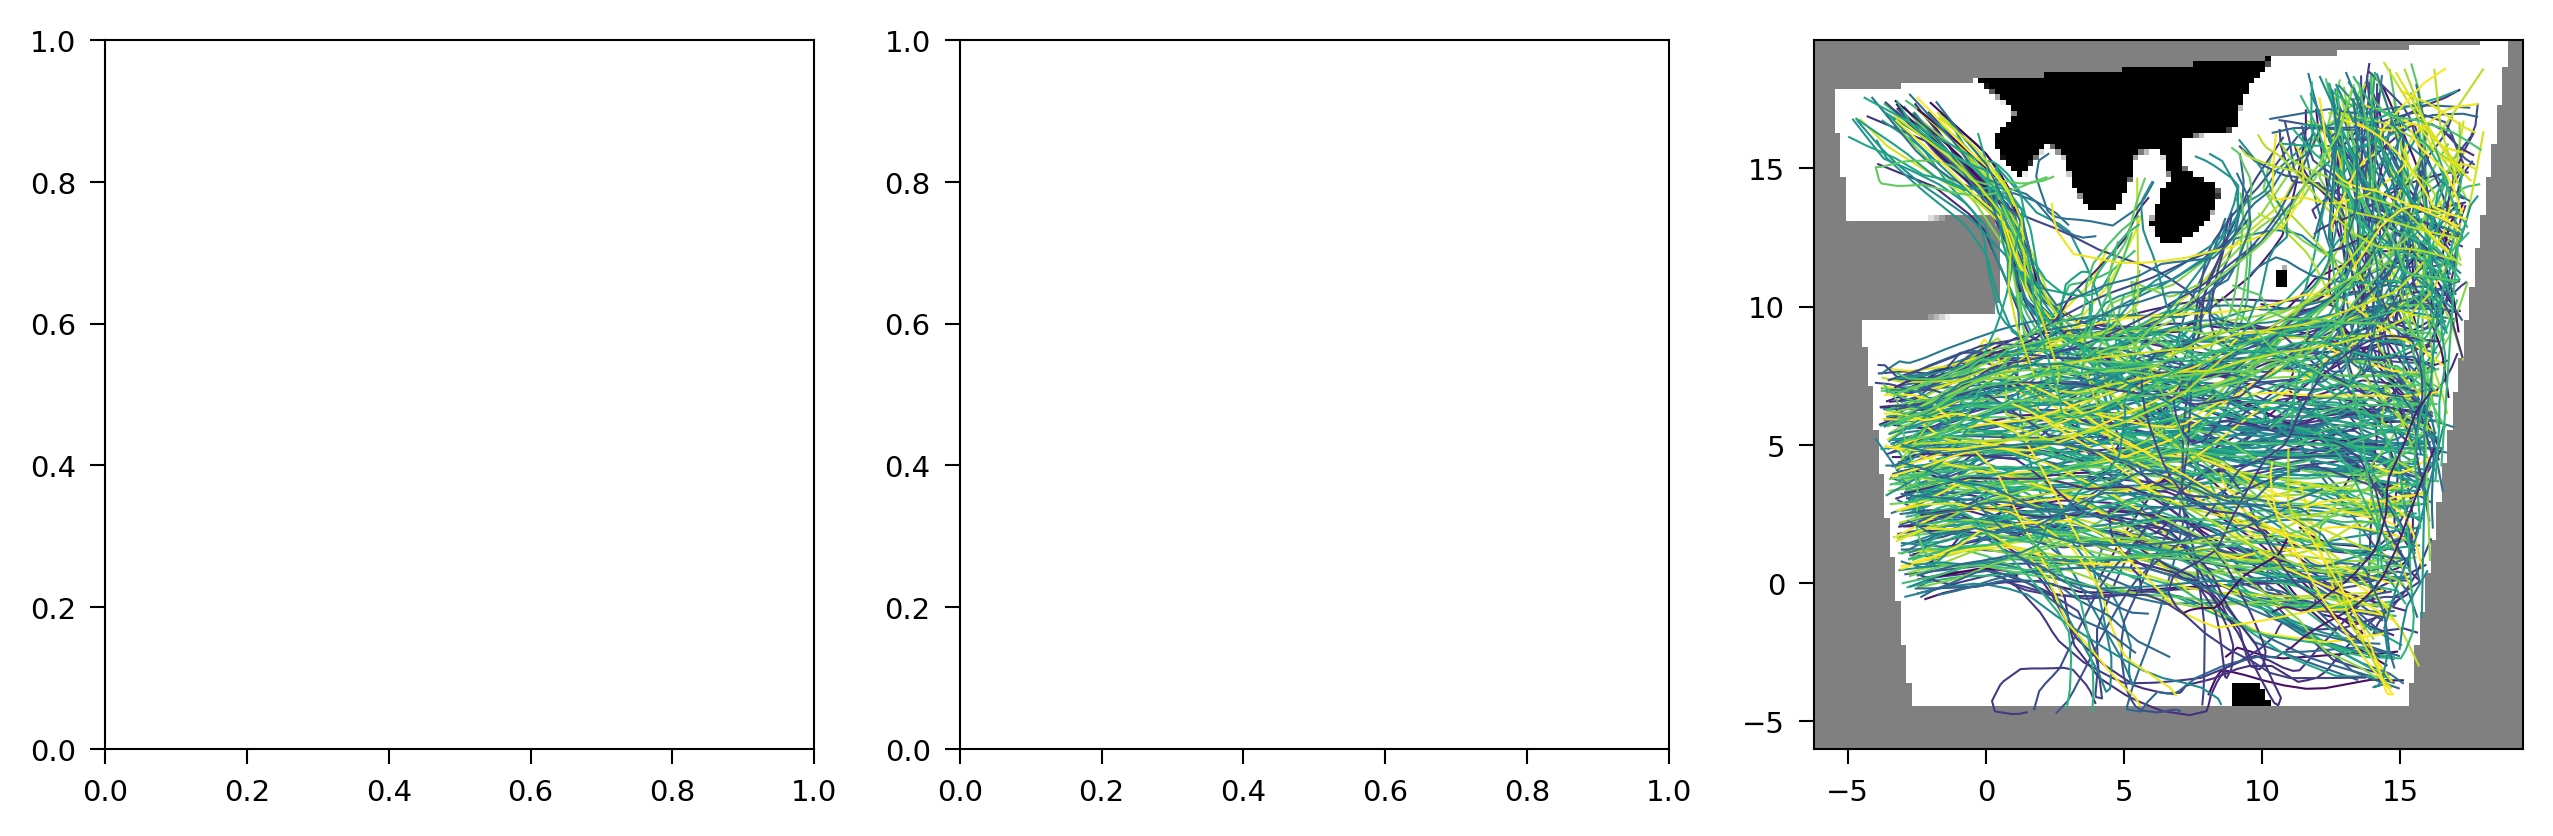

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
from io import StringIO
from pathlib import Path
import matplotlib.pyplot as plt
from src.utils.homography import affine_transformation, image_to_world
from src.dataset.base_dataset import BaseDataset
from src.dataset.ucy_dataset import UCYDataset
from src.utils.plot import get_fig

data_path = Path('data/UCY/data/data_university_students/students003.vsp')

## 读取数据
df_list = []
with open(data_path, 'r') as f:
    P = int(f.readline().split(' ')[0])  # 行人数
    for p in range(P):
        S = int(f.readline().split(' ')[0])  # 控制柄数
        csv = [f.readline().removesuffix(' - (2D point, m_id)') for _ in range(S)]
        df = pd.read_csv(
            StringIO('\n'.join(csv)),
            sep=" ",
            nrows=S,
            usecols=[0, 1, 2, 3],
            names=["x", "y", "f", "direction"],
        )
        df["id"] = p
        df['type'] = 'pedestrian'
        df_list.append(df)
df_data = pd.concat(df_list, ignore_index=True)
df_data = df_data[['f', 'id', 'x', 'y', 'type']]
df_data['x'] += 360
df_data['y'] += 288

## 仿射变换
H = UCYDataset.get_homography_mat(mat_name=data_path.stem)
df_data[['raw_x', 'raw_y']] = df_data[['x', 'y']]
df_data[['x', 'y']] = affine_transformation(df_data[['x', 'y']].values, H)

## 数据重采样
# df_data = BaseDataset.resample_dataframe(df_data, raw_fps=25, target_fps=2.5)

## 创建地图
image_path = data_path.parent / f"{data_path.stem}.png"
raw_image = np.array(Image.open(image_path).convert('L')) / 255.0  # (H, W) 第一维向下，第二维向右
image = raw_image[::-1].T  # 上下翻转并转置，使得第一维向右，第二维向上，与 df_data 中的坐标系对齐
map, xmin, xmax, ymin, ymax = image_to_world(image, H, dot_per_meter=5)  # 第一维向右，第二维向上，观感上与之前保持对齐

## 可视化
fi, fig, axes = get_fig(1, 3, AW=6, AH=6, HS=5, dpi=300)

h, w = raw_image.shape[:2]
axes[0].imshow(raw_image, origin='upper', extent=(0, w, 0, h))  # 第一维向下、第二维向右：直接用 imshow 显示
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    axes[0].plot(group['raw_x'], group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))  # 第一维向右、第二维向上：正常 xy 绘制
axes[0].axis('equal')

w, h = image.shape[:2]
axes[1].imshow(image.T, origin='lower', extent=(0, w, 0, h), cmap='gray_r')  # 第一维向下、第二维向右：直接用 imshow 显示
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    axes[1].plot(group['raw_x'], group['raw_y'], color=cmap(group['f'].max() / df_data['f'].max()))  # 第一维向右、第二维向上：正常 xy 绘制
axes[1].axis('equal')

axes[2].imshow(map.T, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')  # 第一维向右、第二维向上：需要设置 origin='lower'
for pid, group in df_data.groupby('id'):
    cmap = plt.cm.get_cmap('viridis')
    axes[2].plot(group['x'], group['y'], color=cmap(group['f'].max() / df_data['f'].max()))
axes[2].set_facecolor('gray')
axes[2].axis('equal')

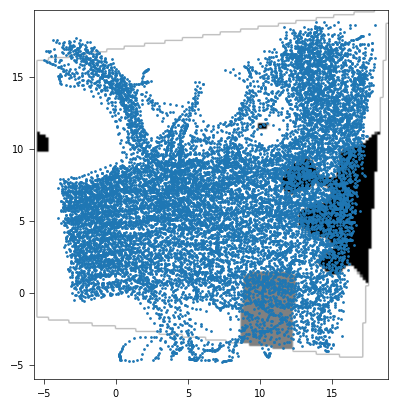

In [ ]:
## 读取数据
df_list = []
with open(data_path, 'r') as f:
    P = int(f.readline().split(' ')[0])  # 行人数
    for p in range(P):
        S = int(f.readline().split(' ')[0])  # 控制柄数
        csv = [f.readline().removesuffix(' - (2D point, m_id)') for _ in range(S)]
        df = pd.read_csv(
            StringIO('\n'.join(csv)),
            sep=" ",
            nrows=S,
            usecols=[0, 1, 2, 3],
            names=["x", "y", "f", "direction"],
        )
        df["id"] = p
        df['type'] = 'pedestrian'
        df_list.append(df)
df_data = pd.concat(df_list, ignore_index=True)
df_data = df_data[['f', 'id', 'x', 'y', 'type']]
df_data['x'] += 360
df_data['y'] += 288

## 仿射变换
H = UCYDataset.get_homography_mat(mat_name=data_path.stem)
# H = np.eye(3)
df_data[['x', 'y']] = affine_transformation(df_data[['x', 'y']].values, H)

image_path = data_path.parent / f"{data_path.stem}.png"
image = np.array(Image.open(image_path).convert('L')) / 255.0 # (H, W)
image = image[::-1].T # 转置并上下翻转，使得第一维向右，第二维向上，与 df_data 中的坐标系对齐
map, xmin, xmax, ymin, ymax = image_to_world(image, H, dot_per_meter=5)


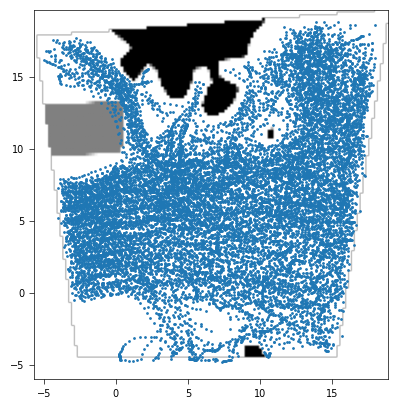

In [5]:
plt.imshow(map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')
plt.scatter(df_data['x'], df_data['y'], s=1)

# Backup

In [ ]:
# 必须先渲染
fig.canvas.draw()
# 获取 bbox 并转换为英寸单位
bbox = axes[0].get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
# 保存图片
fig.savefig("ax.png", bbox_inches=bbox)

In [ ]:
import os
import sys
import torch
import logging
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from io import StringIO
from pathlib import Path
from argparse import Namespace
from src.utils.homography import calc_homography_mat, affine_transformation, image_to_world
from src.dataset.base_dataset import BaseDataset
from src.dataset.ucy_dataset import UCYDataset
from typing import List

data_path = Path('data/UCY/data/data_zara/crowds_zara01.vsp')

## 读取数据
df_list = []
with open(data_path, 'r') as f:
    P = int(f.readline().split(' ')[0])  # 行人数
    for p in range(P):
        S = int(f.readline().split(' ')[0])  # 控制柄数
        csv = [f.readline().removesuffix(' - (2D point, m_id)') for _ in range(S)]
        df = pd.read_csv(
            StringIO('\n'.join(csv)),
            sep=" ",
            nrows=S,
            usecols=[0, 1, 2, 3],
            names=["x", "y", "f", "direction"],
        )
        df["id"] = p
        df['type'] = 'pedestrian'
        df_list.append(df)
df_data = pd.concat(df_list, ignore_index=True)
df_data = df_data[['f', 'id', 'x', 'y', 'type']]
df_data['x'] += 360
df_data['y'] += 288
# df_data['x'] /= 2
# df_data['y'] /= 2

## 数据重采样
df_data = BaseDataset.resample_dataframe(df_data, raw_fps=25, target_fps=2.5)

## 仿射变换
H = UCYDataset.get_homography_mat(mat_name=data_path.stem)
# df_data[['world_x', 'world_y']] = affine_transformation(df_data[['x', 'y']].values, H)

## 创建地图
image_path = data_path.parent / f"{data_path.stem}.png"
image = np.array(Image.open(image_path).convert('L'))[::-1].T  # (H, W)
# map, xmin, xmax, ymin, ymax = image_to_world(image, H, dot_per_meter=5)



In [95]:
length, width = 5., 8.
post1 = np.array([[32, 73], [630, 80], [78, 341], [593, 342]]) # - np.array([[360, 288]])
post2 = np.array([[0, 0], [width, 0], [0, length], [width, length]])

In [97]:
image[32, 73] = 128
image[630, 80] = 128
image[78, 341] = 128
image[593, 342] = 128

C:\Users\YuMeow\AppData\Local\Temp\ipykernel_54552\4242811676.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


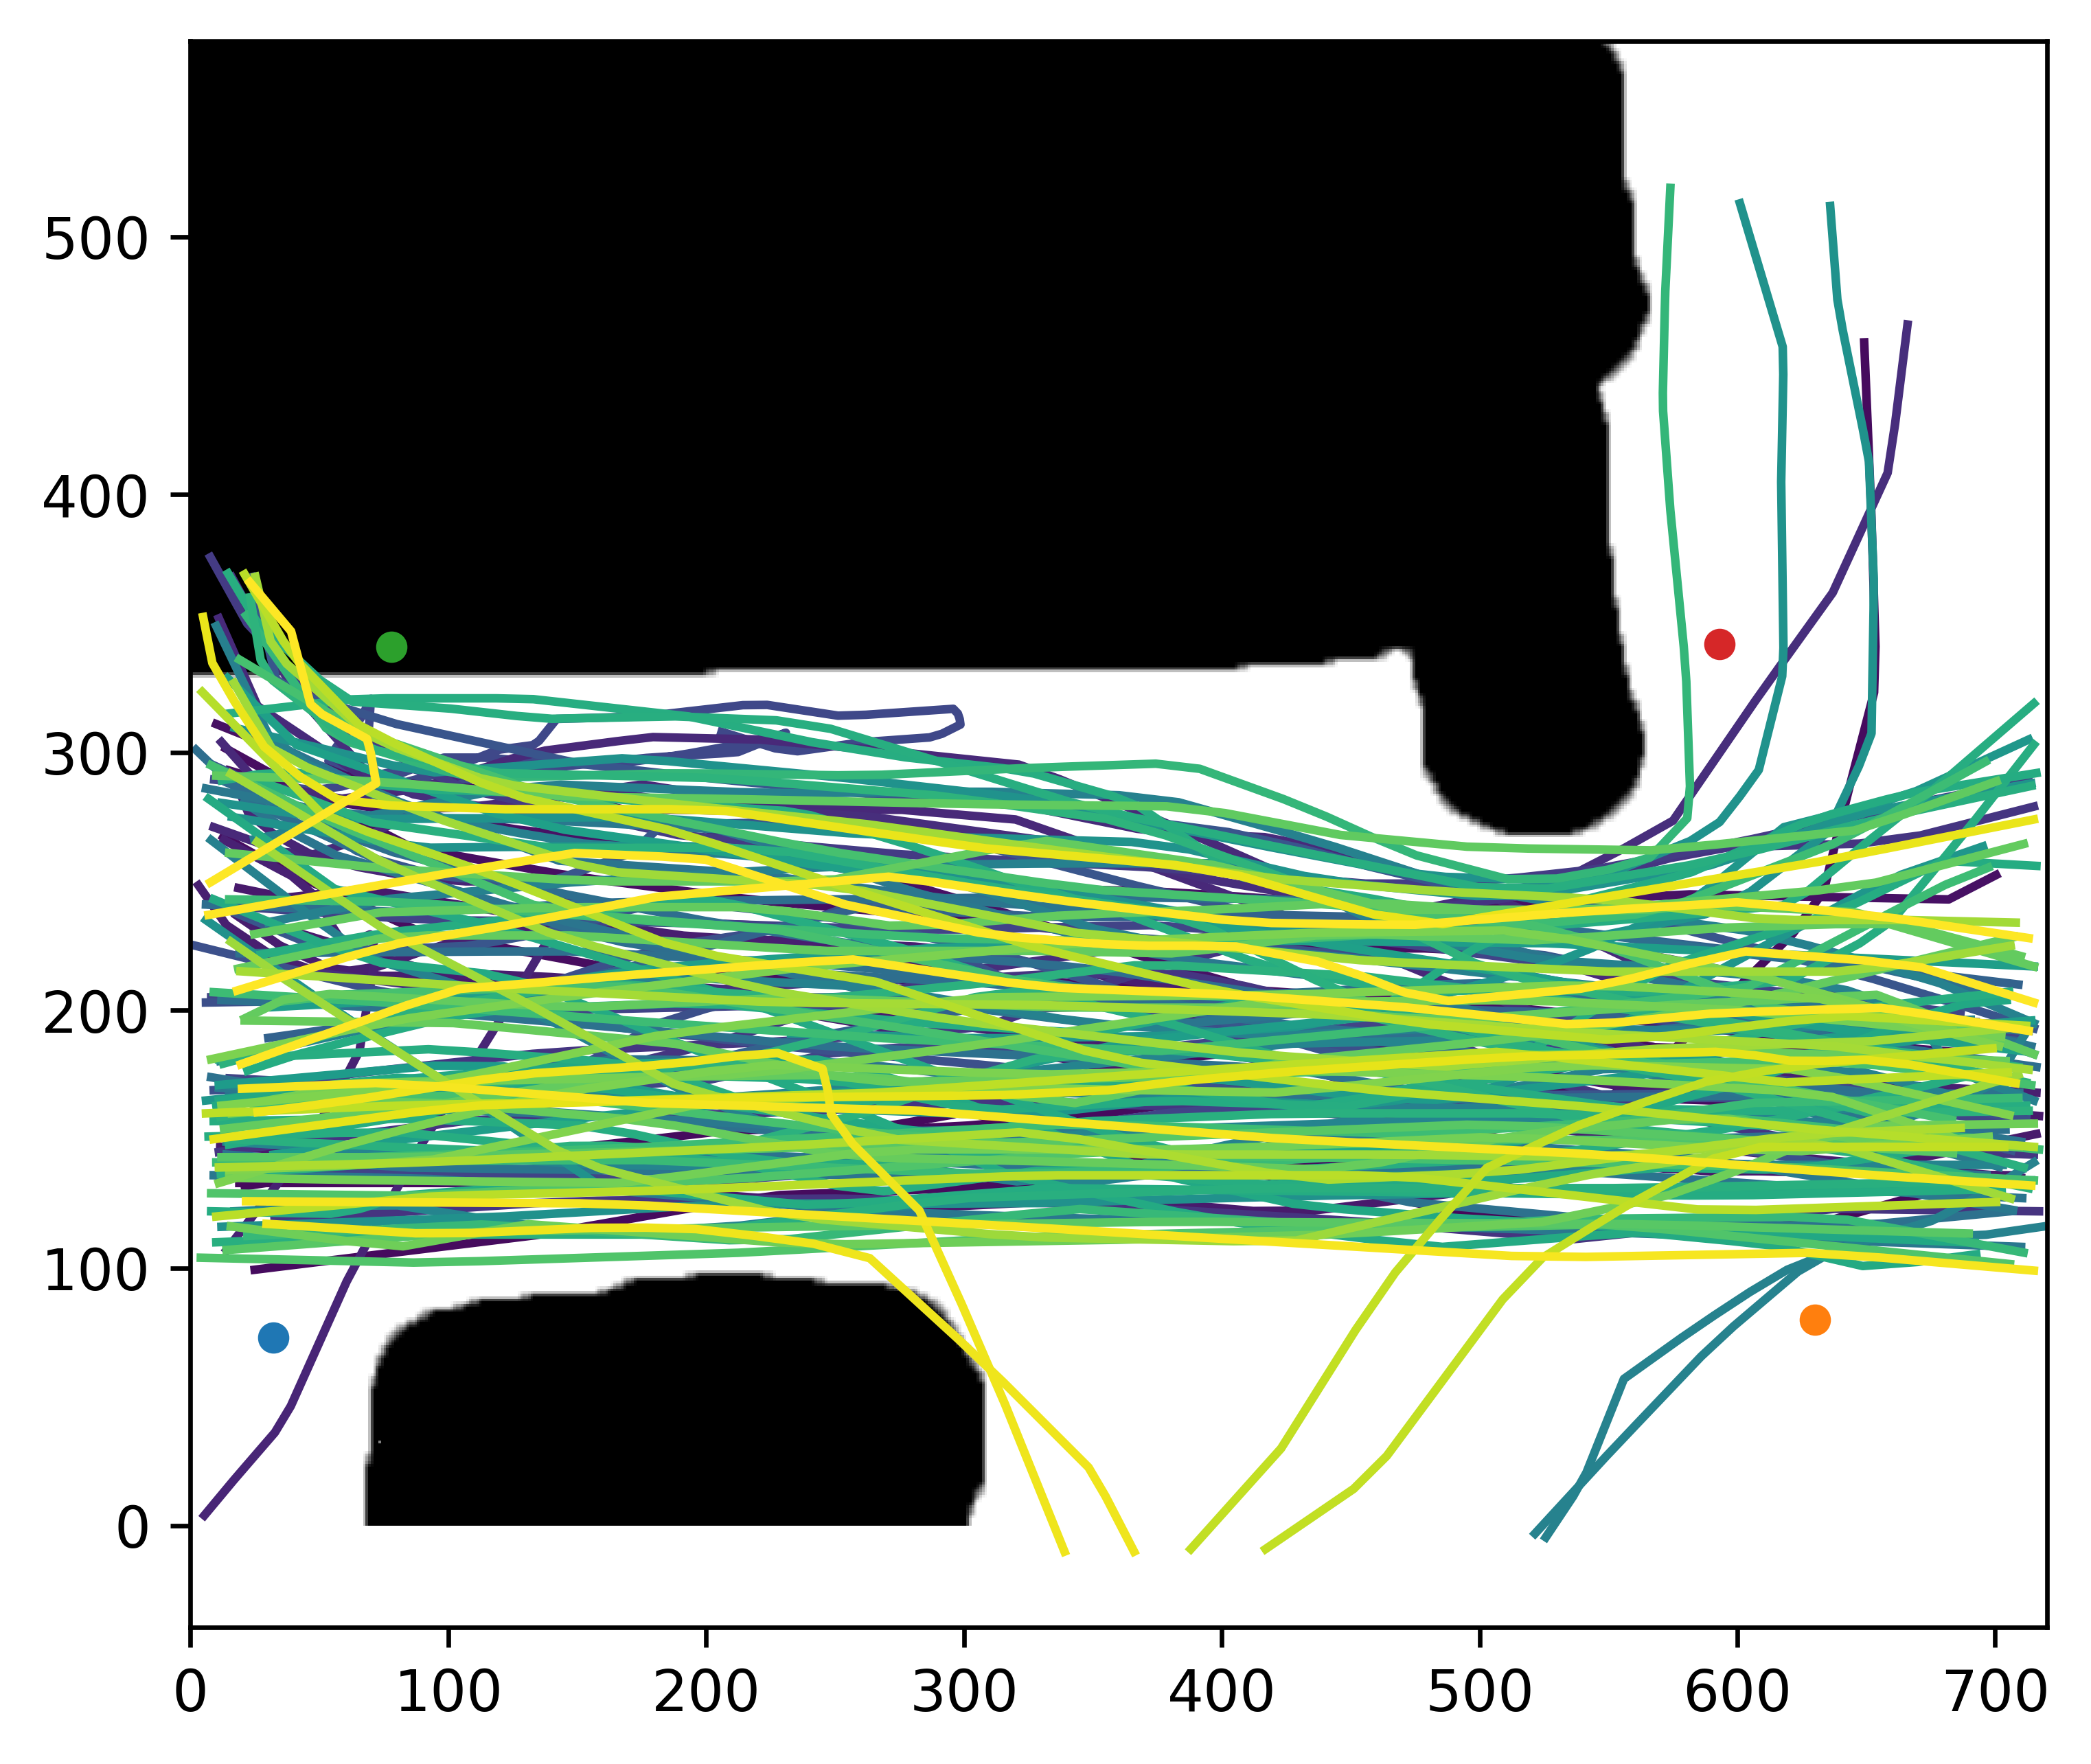

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5), dpi=600)
plt.imshow(image.T[::-1], extent=(0, w, 0, h), cmap='gray_r')

cmap = plt.cm.get_cmap('viridis')
for pid, group in df_data.groupby('id'):
    plt.plot(group['x'], group['y'], color=cmap(group['f'].max() / df_data['f'].max()))

for p in post1:
    plt.scatter(p[0], p[1], s=20)

In [119]:
from scipy.interpolate import griddata
src = image
dot_per_meter = 10

h, w = src.shape[:2]
value = src.reshape(h*w, *src.shape[2:])  # (h*w, ...)

xx, yy = np.meshgrid(np.arange(h), np.arange(w), indexing="ij") # (h, w)
src_coord = np.stack([xx, yy], axis=-1).astype(np.float32)  # (h, w, 2)
tgt_coord = affine_transformation(src_coord, H)  # (h, w, 2)
x = tgt_coord[..., 0].reshape(-1)
y = tgt_coord[..., 1].reshape(-1)
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
xx, yy = np.meshgrid(
    np.arange(xmin, xmax+1/dot_per_meter, 1/dot_per_meter)[:-1],
    np.arange(ymin, ymax+1/dot_per_meter, 1/dot_per_meter)[:-1],
)
map = griddata(
    points=np.stack([x, y], axis=-1),
    values=value,
    xi=(xx, yy),
    method="linear",  # 'linear' 对应双线性插值
)

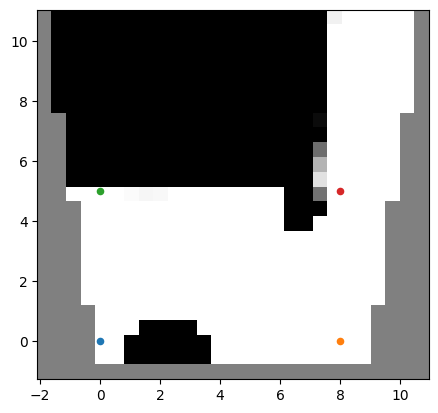

In [ ]:
import matplotlib.pyplot as plt


plt.imshow(map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')

df_data[['world_x', 'world_y']] = affine_transformation(df_data[['x', 'y']].values, H)

cmap = plt.cm.get_cmap('viridis')
for pid, group in df_data.groupby('id'):
    plt.plot(group['world_x'], group['world_y'], color=cmap(group['f'].max() / df_data['f'].max()))

for p in post2:
    plt.scatter(p[0], p[1], s=20)

plt.gca().set_facecolor('gray')

C:\Users\YuMeow\AppData\Local\Temp\ipykernel_54552\4253421881.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


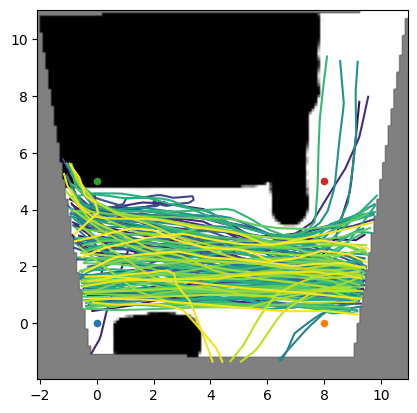

In [121]:
import matplotlib.pyplot as plt


plt.imshow(map, origin='lower', extent=(xmin, xmax, ymin, ymax), cmap='gray_r')

df_data[['world_x', 'world_y']] = affine_transformation(df_data[['x', 'y']].values, H)

cmap = plt.cm.get_cmap('viridis')
for pid, group in df_data.groupby('id'):
    plt.plot(group['world_x'], group['world_y'], color=cmap(group['f'].max() / df_data['f'].max()))

for p in post2:
    plt.scatter(p[0], p[1], s=20)

plt.gca().set_facecolor('gray')